In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url_featured = 'https://raw.githubusercontent.com/SrHunterDeer/project1/main/project%20managerment/data/featured_data%20(1).csv'
df = pd.read_csv(url_featured)
if 'ACCOUNT_ID' in df.columns:
    df = df.drop(columns=['ACCOUNT_ID'])

In [30]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
X = df.drop(columns=['NEXT_MONTH_DEFAULT'])
y = df['NEXT_MONTH_DEFAULT']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

BÁO CÁO MÔ HÌNH:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      4938
           1       0.64      0.59      0.61      1651

    accuracy                           0.81      6589
   macro avg       0.75      0.74      0.75      6589
weighted avg       0.81      0.81      0.81      6589

Chỉ số AUC: 0.8160


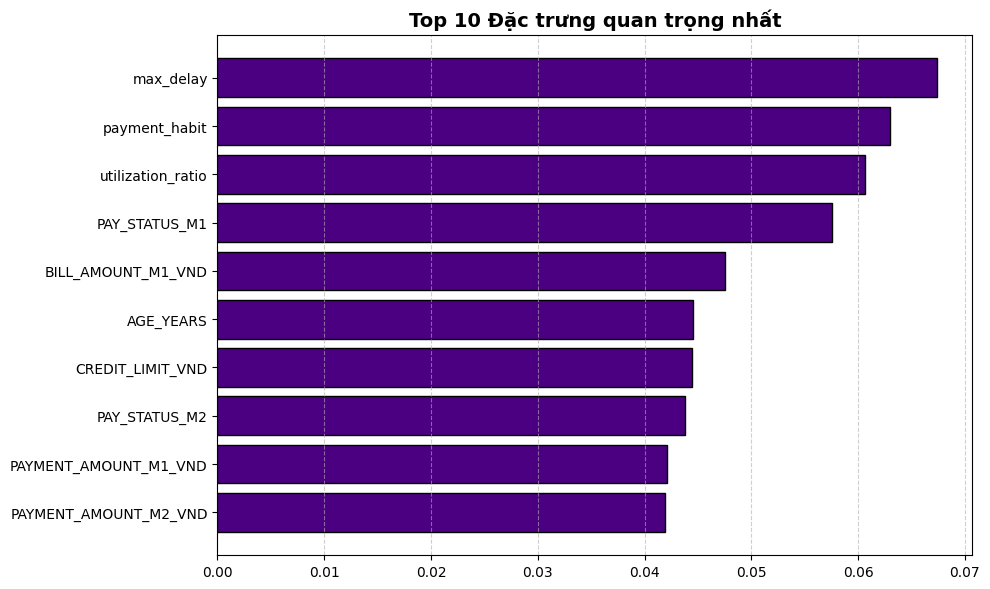

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
print("BÁO CÁO MÔ HÌNH:")
print(classification_report(y_test, y_pred))
print(f"Chỉ số AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]
features = X.columns
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='#4B0082', edgecolor='black')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Top 10 Đặc trưng quan trọng nhất', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


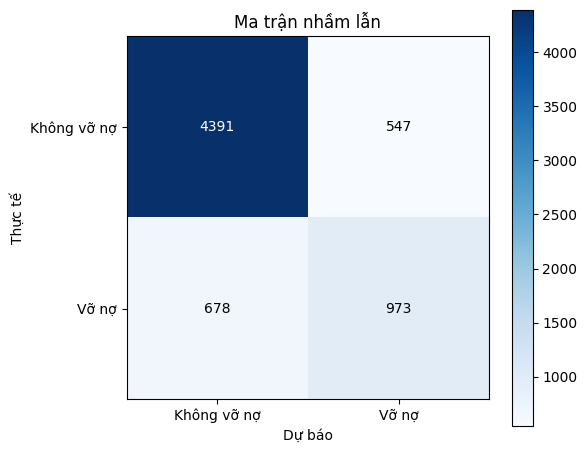

In [28]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=['Không vỡ nợ', 'Vỡ nợ'], 
       yticklabels=['Không vỡ nợ', 'Vỡ nợ'],
       title='Ma trận nhầm lẫn',
       ylabel='Thực tế',
       xlabel='Dự báo')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2. else "black")
plt.tight_layout()
plt.show()